In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [54]:
df=pd.read_csv("heart.csv")

In [55]:
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


EDA


In [56]:
 df.shape

(918, 12)

In [57]:
df.shape

(918, 12)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [59]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


CHECKING DUPLICATES

In [60]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

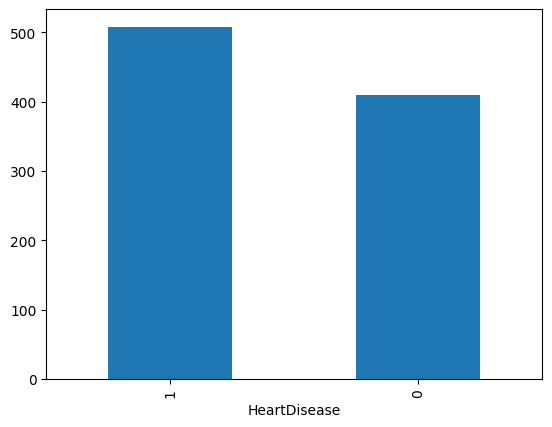

In [61]:
df['HeartDisease'].value_counts().plot(kind='bar')

CHECKING WHETHER NULL VALUE IS THERE OR NOT

In [62]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [63]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

FOR NUMERICAL DATA 
MAKING HISTPLOT 

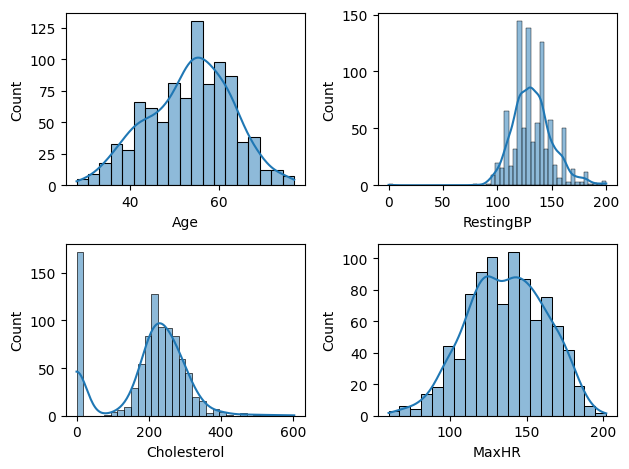

In [64]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)
    
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()


In [65]:

!pip install sheryanalysis==0.1.0

NOW DOING VALUE.COUNTS() OF CHOLESTROL BCOZ CHOLESTEROL CAN'T BE 0
THERE IS SOMETHING WRONG IN DATA SO I'LL TRY TO MAKE DATA CORRECT

In [66]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
220     10
223     10
204      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

FINDING MEAN OF CHOLESTROL EXCEPT 0 

In [67]:
ch_mean=df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()

In [68]:
ch_mean

np.float64(244.6353887399464)

NOW , WE WILL REPLACE THE MEAN WITH THE 0 

In [69]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol']=df['Cholesterol'].round(2)

DOING SAME FOR RESTING BP

In [70]:
resting_bp_means=df.loc[df['RestingBP']!=0,'RestingBP'].mean()
df['resting BP'] = df['RestingBP'].replace(0,resting_bp_means)
df['resting BP']=df['resting BP'].round(2)

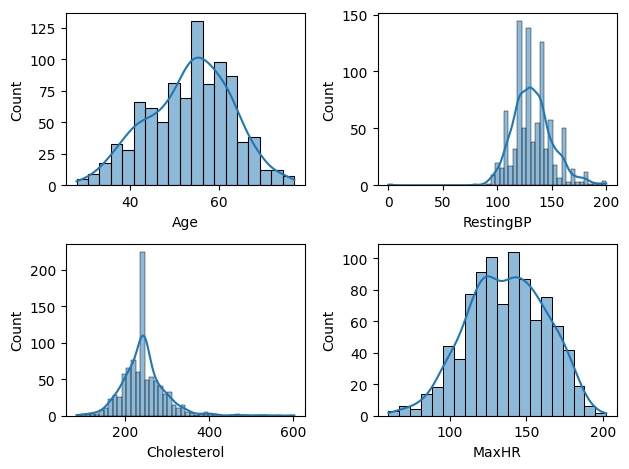

In [71]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)
    
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()


<Axes: xlabel='Sex', ylabel='count'>

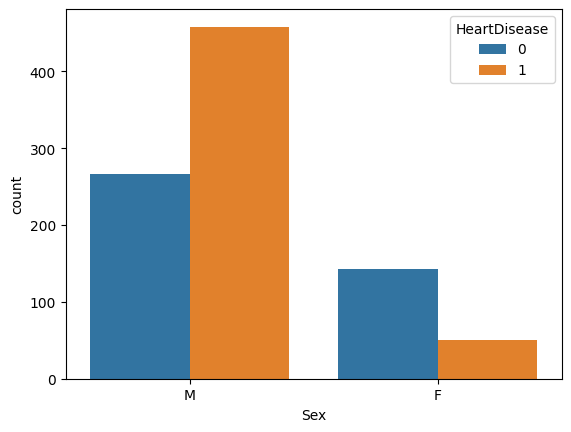

In [72]:
sns.countplot(x='Sex', hue='HeartDisease', data=df)

In [73]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,resting BP
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,244.636253,0.233115,136.809368,0.887364,0.553377,132.540893
std,9.432617,18.514154,53.318029,0.423046,25.460334,1.066570,0.497414,17.989932
min,28.000000,0.000000,85.000000,0.000000,60.000000,-2.600000,0.000000,80.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000,120.000000
50%,54.000000,130.000000,244.640000,0.000000,138.000000,0.600000,1.000000,130.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000,140.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000,200.000000


In [74]:
df.count()

Age               918
Sex               918
ChestPainType     918
RestingBP         918
Cholesterol       918
FastingBS         918
RestingECG        918
MaxHR             918
ExerciseAngina    918
Oldpeak           918
ST_Slope          918
HeartDisease      918
resting BP        918
dtype: int64

<Axes: xlabel='ChestPainType', ylabel='count'>

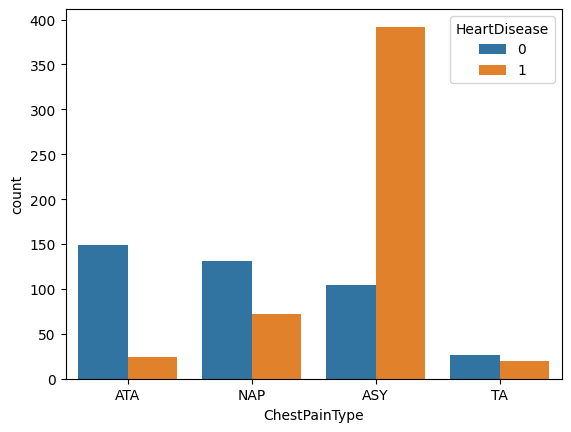

In [75]:
sns.countplot(x='ChestPainType', hue='HeartDisease', data=df)

<Axes: xlabel='FastingBS', ylabel='count'>

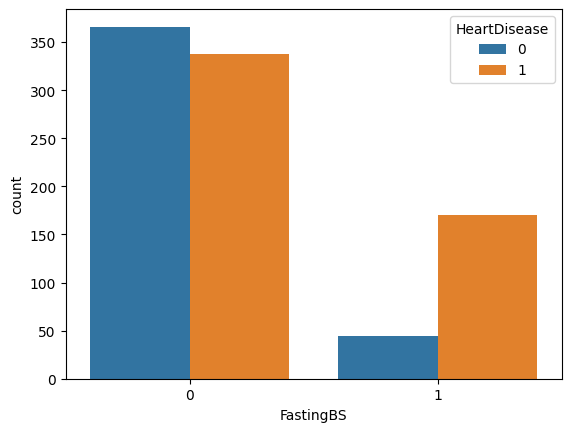

In [76]:
sns.countplot(x='FastingBS', hue='HeartDisease', data=df)

Situation	                                Tool

DATA VS DATA                              USED 

Numeric vs Numeric  ------------------->   Scatterplot
Categorical vs Numeric ---------------->	Boxplot
Categorical vs Categorical	----------->   Countplot

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

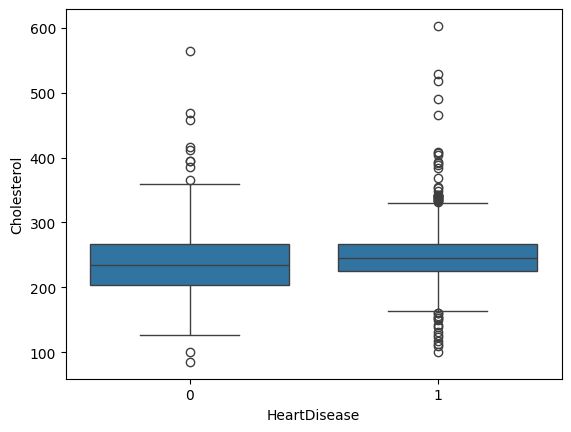

In [77]:
sns.boxplot(x='HeartDisease',y='Cholesterol',data=df)




<Axes: xlabel='HeartDisease', ylabel='RestingBP'>

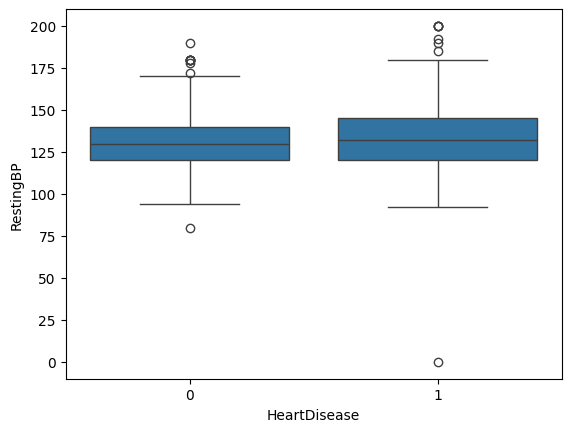

In [78]:
sns.boxplot(x='HeartDisease',y='RestingBP',data=df)

<Axes: >

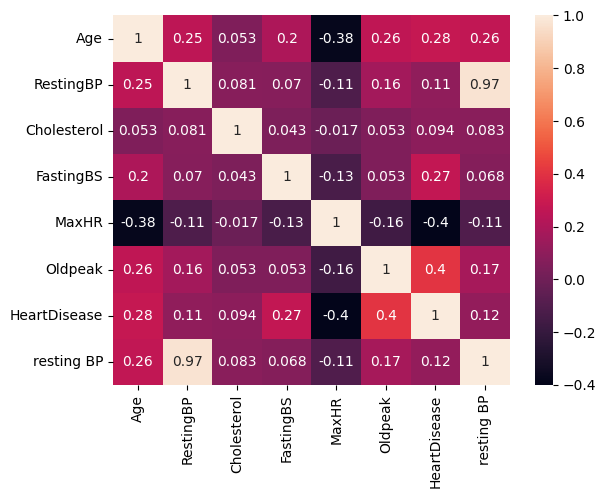

In [79]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

DATA PREPROCESSING AND CLEANING

In [80]:
#instead of creating dummies we can directly use encode
# isse jitne bhi honge hot encoding wale sbke alg alg create ho jayenge
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,resting BP
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0,140.0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1,160.0
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0,130.0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1,138.0
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0,150.0


In [81]:

df_encoded = pd.get_dummies(df,drop_first=True)

In [82]:
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,resting BP,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289.0,0,172,0.0,0,140.0,True,True,False,False,True,False,False,False,True
1,49,160,180.0,0,156,1.0,1,160.0,False,False,True,False,True,False,False,True,False
2,37,130,283.0,0,98,0.0,0,130.0,True,True,False,False,False,True,False,False,True
3,48,138,214.0,0,108,1.5,1,138.0,False,False,False,False,True,False,True,True,False
4,54,150,195.0,0,122,0.0,0,150.0,True,False,True,False,True,False,False,False,True


In [83]:

df_encoded = df_encoded.astype(int)

In [84]:

df_encoded.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'resting BP', 'Sex_M', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal',
       'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [85]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [86]:

X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42)

In [88]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [89]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM (RBF Kernel)": SVC(probability=True)
}

In [90]:

results = []

In [91]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4)
    })

In [92]:
results

[{'Model': 'Logistic Regression', 'Accuracy': 0.8804, 'F1 Score': 0.8932},
 {'Model': 'KNN', 'Accuracy': 0.8804, 'F1 Score': 0.8932},
 {'Model': 'Naive Bayes', 'Accuracy': 0.8696, 'F1 Score': 0.8788},
 {'Model': 'Decision Tree', 'Accuracy': 0.7554, 'F1 Score': 0.7668},
 {'Model': 'SVM (RBF Kernel)', 'Accuracy': 0.8641, 'F1 Score': 0.8792}]

            AB FRONTEND K LIA HUME PICKLE FILE MEIN KRNA HOGA MODEL SAVE

In [93]:

import joblib
joblib.dump(models['KNN'],'KNN_heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']

svm